<a href="https://colab.research.google.com/github/Geethanjali-345/19032024/blob/geethanjali/minor1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
  import matplotlib.pyplot as plt
import seaborn as snb
import string

In [ ]:
import pandas as pd
from google.colab import files
uploaded=files.upload()
data=pd.read_csv('fake_job_postings.csv')
data.head()

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17880 entries, 0 to 17879
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   job_id               17880 non-null  int64 
 1   title                17880 non-null  object
 2   location             17534 non-null  object
 3   department           6333 non-null   object
 4   salary_range         2868 non-null   object
 5   company_profile      14572 non-null  object
 6   description          17879 non-null  object
 7   requirements         15185 non-null  object
 8   benefits             10670 non-null  object
 9   telecommuting        17880 non-null  int64 
 10  has_company_logo     17880 non-null  int64 
 11  has_questions        17880 non-null  int64 
 12  employment_type      14409 non-null  object
 13  required_experience  10830 non-null  object
 14  required_education   9775 non-null   object
 15  industry             12977 non-null  object
 16  func

In [ ]:
data.columns

Index(['job_id', 'title', 'location', 'department', 'salary_range',
       'company_profile', 'description', 'requirements', 'benefits',
       'telecommuting', 'has_company_logo', 'has_questions', 'employment_type',
       'required_experience', 'required_education', 'industry', 'function',
       'fraudulent'],
      dtype='object')

In [ ]:
data.isnull().sum()

job_id                     0
title                      0
location                 346
department             11547
salary_range           15012
company_profile         3308
description                1
requirements            2695
benefits                7210
telecommuting              0
has_company_logo           0
has_questions              0
employment_type         3471
required_experience     7050
required_education      8105
industry                4903
function                6455
fraudulent                 0
dtype: int64

In [ ]:
data.drop(['job_id' , 'salary_range' , 'telecommuting' , 'has_company_logo' , 'has_questions'] , axis = 1,inplace = True)

In [ ]:
data.head()

,title,location,department,company_profile,description,requirements,benefits,employment_type,required_experience,required_education,industry,function,fraudulent
0,Marketing Intern,"US, NY, New York",Marketing,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,Other,Internship,NaN,NaN,Marketing,0
1,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,NaN,NaN,NaN,NaN,NaN,0
3,Account Executive - Washington DC,"US, DC, Washington",Sales,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0
4,Bill Review Manager,"US, FL, Fort Worth",NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0


In [ ]:
data.shape

(17880, 13)

In [ ]:
data.fillna(' ',inplace=True)

In [ ]:
data.head()

In [ ]:
data.isnull().sum()

title                  0
location               0
department             0
company_profile        0
description            0
requirements           0
benefits               0
employment_type        0
required_experience    0
required_education     0
industry               0
function               0
fraudulent             0
dtype: int64

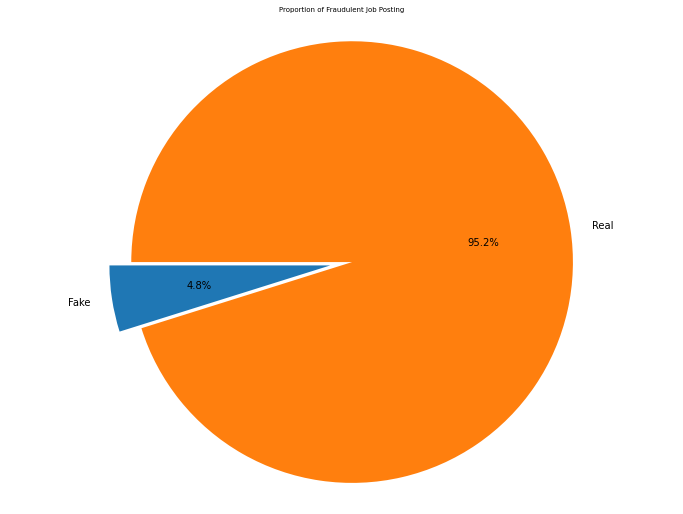

In [ ]:
labels = 'Fake' ,'Real'

sizes = [data.fraudulent[data['fraudulent'] == 1].count() ,data.fraudulent[data['fraudulent'] == 0].count()]
explode =(0,0.1)

fig1 ,ax1 = plt.subplots(figsize =(12,9))
ax1.pie(sizes ,explode =explode, labels =labels, autopct ='%1.1f%%',startangle =180)

ax1.axis('equal')
plt.title("Proportion of Fraudulent Job Posting" ,size =7)
plt.show()

In [ ]:
def split(location):
  l =location.split(',')
  return l[0]

data['country'] =data.location.apply(split)

In [ ]:
data['country'].nunique()

91

In [ ]:
data['country'].value_counts()[:11]

US    10656
GB     2384
GR      940
CA      457
DE      383
        346
NZ      333
IN      276
AU      214
PH      132
NL      127
Name: country, dtype: int64

Text(0, 0.5, 'Number of Jobs')

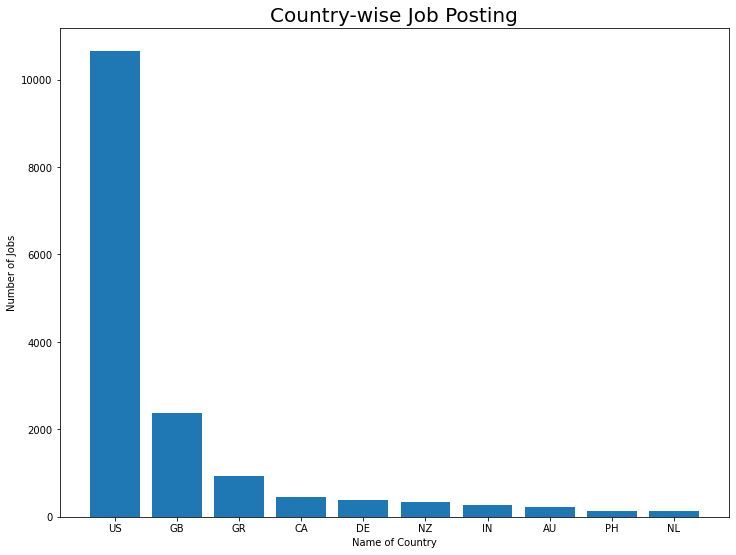

In [ ]:
country =dict(data.country.value_counts()[:11])

del country[' ']
plt.figure(figsize=(12,9))

plt.title('Country-wise Job Posting',size=20)
plt.bar(country.keys(),country.values())

plt.xlabel('Name of Country')
plt.ylabel('Number of Jobs')

Text(0, 0.5, 'Number of Jobs')

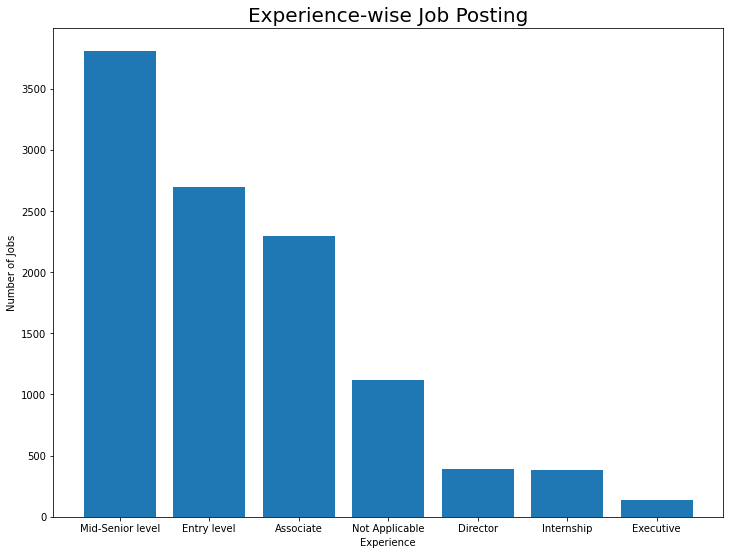

In [ ]:
experience =dict(data.required_experience.value_counts()[:11])

del experience[' ']
plt.figure(figsize=(12,9))

plt.title('Experience-wise Job Posting',size=20)
plt.bar(experience.keys(),experience.values())

plt.xlabel('Experience')
plt.ylabel('Number of Jobs')

Text(0, 0.5, 'Number of Jobs')

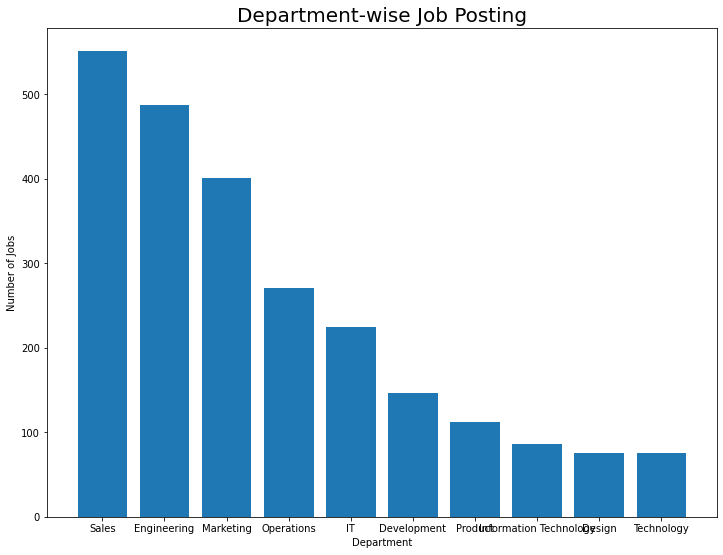

In [ ]:
department1 =dict(data.department.value_counts()[:11])

del department1[' ']
plt.figure(figsize=(12,9))

plt.title('Department-wise Job Posting',size=20)
plt.bar(department1.keys(),department1.values())

plt.xlabel('Department')
plt.ylabel('Number of Jobs')

In [ ]:
data.title.value_counts()[:11]

English Teacher Abroad                                311
Customer Service Associate                            146
Graduates: English Teacher Abroad (Conversational)    144
English Teacher Abroad                                 95
Software Engineer                                      86
English Teacher Abroad (Conversational)                83
Customer Service Associate - Part Time                 76
Account Manager                                        75
Web Developer                                          66
Project Manager                                        62
Beauty & Fragrance consultants needed                  60
Name: title, dtype: int64

In [ ]:
data[data.fraudulent == 1].title.value_counts()[:11]

Data Entry Admin/Clerical Positions - Work From Home                    21
Home Based Payroll Typist/Data Entry Clerks Positions Available         21
Cruise Staff Wanted *URGENT*                                            21
Customer Service Representative                                         17
Administrative Assistant                                                16
Home Based Payroll Data Entry Clerk Position - Earn $100-$200 Daily     12
Account Sales Managers $80-$130,000/yr                                  10
Network Marketing                                                       10
Payroll Clerk                                                           10
Payroll Data Coordinator Positions - Earn $100-$200 Daily               10
Data Entry                                                               9
Name: title, dtype: int64

In [ ]:
data[data.fraudulent == 0].title.value_counts()[:11]

English Teacher Abroad                                311
Customer Service Associate                            146
Graduates: English Teacher Abroad (Conversational)    144
English Teacher Abroad                                 95
Software Engineer                                      86
English Teacher Abroad (Conversational)                83
Customer Service Associate - Part Time                 76
Account Manager                                        73
Web Developer                                          66
Project Manager                                        62
Beauty & Fragrance consultants needed                  60
Name: title, dtype: int64

In [ ]:
data.columns

Index(['title', 'location', 'department', 'company_profile', 'description',
       'requirements', 'benefits', 'employment_type', 'required_experience',
       'required_education', 'industry', 'function', 'fraudulent', 'country'],
      dtype='object')

In [ ]:
data['text'] = data['title'] + ' '+ data['location'] + ' ' + data['department'] + ' ' + data['company_profile'] + ' '+ data['description'] + ' ' + data['requirements'] + ' ' + data['benefits'] + ' ' + data['industry']

del data['title']
del data['location']
del data['department']
del data['company_profile']
del data['description']
del data['requirements']
del data['benefits']
del data['employment_type']
del data['required_experience']
del data['required_education']
del data['industry']
del data['function']
del data['country']

In [ ]:
data.head()

,fraudulent,text
0,0,"Marketing Intern US, NY, New York Marketing We..."
1,0,"Customer Service - Cloud Video Production NZ, ..."
2,0,"Commissioning Machinery Assistant (CMA) US, IA..."
3,0,"Account Executive - Washington DC US, DC, Wash..."
4,0,"Bill Review Manager US, FL, Fort Worth SpotS..."


In [ ]:
from wordcloud import WordCloud
all_words = ' '.join([text for text in data['text']])

In [ ]:
wordcloud = WordCloud(width = 600 ,height = 300, max_font_size = 120).generate(all_words)

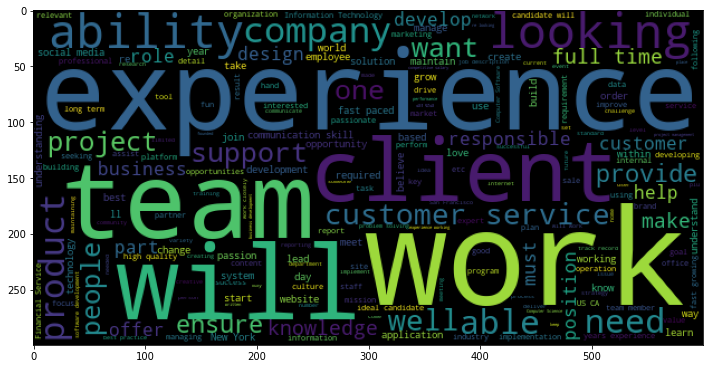

In [ ]:
plt.figure(figsize =(12,9))

plt.imshow(wordcloud)
plt.show()

In [ ]:
real_post = ' '.join([text for text in data['text'][data['fraudulent']==0]])

In [ ]:
wordcloud1 = WordCloud(width = 600 ,height = 300, max_font_size = 120).generate(real_post)

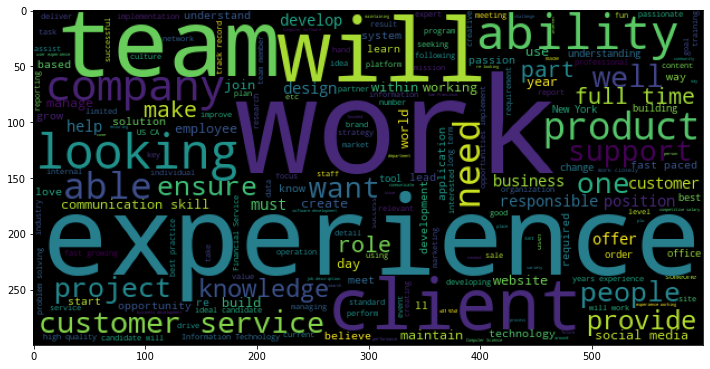

In [ ]:
plt.figure(figsize =(12,9))

plt.imshow(wordcloud1)
plt.show()


In [ ]:
fake_post = ' '.join([text for text in data['text'][data['fraudulent'] == 1]])

In [ ]:
wordcloud2 = WordCloud(width = 600 ,height = 300, max_font_size = 120).generate(fake_post)

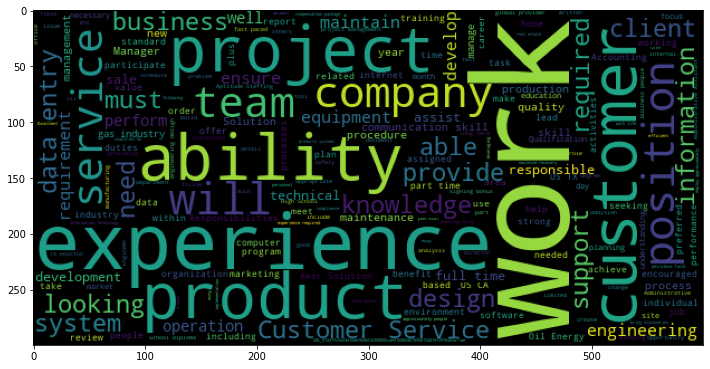

In [ ]:
plt.figure(figsize =(12,9))

plt.imshow(wordcloud2)
plt.show()

In [ ]:
import nltk
nltk.download('stopwords')

from nltk.corpus import stopwords

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
print(stopwords.words("english"))

['i', 'me', 'my', 'myself', 'we', 'our', 'ours', 'ourselves', 'you', "you're", "you've", "you'll", "you'd", 'your', 'yours', 'yourself', 'yourselves', 'he', 'him', 'his', 'himself', 'she', "she's", 'her', 'hers', 'herself', 'it', "it's", 'its', 'itself', 'they', 'them', 'their', 'theirs', 'themselves', 'what', 'which', 'who', 'whom', 'this', 'that', "that'll", 'these', 'those', 'am', 'is', 'are', 'was', 'were', 'be', 'been', 'being', 'have', 'has', 'had', 'having', 'do', 'does', 'did', 'doing', 'a', 'an', 'the', 'and', 'but', 'if', 'or', 'because', 'as', 'until', 'while', 'of', 'at', 'by', 'for', 'with', 'about', 'against', 'between', 'into', 'through', 'during', 'before', 'after', 'above', 'below', 'to', 'from', 'up', 'down', 'in', 'out', 'on', 'off', 'over', 'under', 'again', 'further', 'then', 'once', 'here', 'there', 'when', 'where', 'why', 'how', 'all', 'any', 'both', 'each', 'few', 'more', 'most', 'other', 'some', 'such', 'no', 'nor', 'not', 'only', 'own', 'same', 'so', 'than', '

In [ ]:
stop_words = set(stopwords.words("english"))

In [ ]:
data['text'] = data['text'].apply(lambda x:x.lower())

In [ ]:
data['text'] = data['text'].apply(lambda x:' '.join([word for word in x.split() if word not in(stop_words)]))

In [ ]:
data['text'][0]

"marketing intern us, ny, new york marketing we're food52, we've created groundbreaking award-winning cooking site. support, connect, celebrate home cooks, give everything need one place.we top editorial, business, engineering team. we're focused using technology find new better ways connect people around specific food interests, offer superb, highly curated information food cooking. attract talented home cooks contributors country; also publish well-known professionals like mario batali, gwyneth paltrow, danny meyer. partnerships whole foods market random house.food52 named best food website james beard foundation iacp, featured new york times, npr, pando daily, techcrunch, today show.we're located chelsea, new york city. food52, fast-growing, james beard award-winning online food community crowd-sourced curated recipe hub, currently interviewing full- part-time unpaid interns work small team editors, executives, developers new york city headquarters.reproducing and/or repackaging exi

In [ ]:
from sklearn.model_selection import train_test_split

X_train,X_test ,y_train,y_test = train_test_split(data.text, data.fraudulent ,test_size =0.3)

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

In [ ]:
vect = CountVectorizer()
vect.fit(X_train)

CountVectorizer()

In [ ]:
X_train_dtm = vect.transform(X_train)

In [ ]:
X_train_dtm

<12516x86401 sparse matrix of type '<class 'numpy.int64'>'
	with 2324739 stored elements in Compressed Sparse Row format>

In [ ]:
from sklearn.naive_bayes import  MultinomialNB
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score ,confusion_matrix ,classification_report

In [ ]:
X_test_dtm = vect.transform(X_test)
X_test_dtm

<5364x86401 sparse matrix of type '<class 'numpy.int64'>'
	with 975200 stored elements in Compressed Sparse Row format>

In [ ]:
nb = MultinomialNB()
nb.fit(X_train_dtm, y_train)

MultinomialNB()

In [ ]:
y_pred_nb = nb.predict(X_test_dtm)

In [ ]:
accuracy_score(y_test,y_pred_nb)

0.9752050708426547

In [ ]:
dt = DecisionTreeClassifier()
dt.fit(X_train_dtm,y_train)

DecisionTreeClassifier()

In [ ]:
y_pred_dt = dt.predict(X_test_dtm)

In [ ]:
accuracy_score(y_test,y_pred_dt)

0.9821029082774049

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn import metrics
import numpy as np

In [ ]:
y=data.fraudulent
print(y.head())

0    0
1    0
2    0
3    0
4    0
Name: fraudulent, dtype: int64


In [ ]:
X=data.drop('fraudulent',1)
print(X.head())

                                                text
0  marketing intern us, ny, new york marketing we...
1  customer service - cloud video production nz, ...
2  commissioning machinery assistant (cma) us, ia...
3  account executive - washington dc us, dc, wash...
4  bill review manager us, fl, fort worth spotsou...


/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:1: FutureWarning: In a future version of pandas all arguments of DataFrame.drop except for the argument 'labels' will be keyword-only
  """Entry point for launching an IPython kernel.


In [ ]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.3, random_state=4)
print ('Train set:', X_train.shape,  y_train.shape)
print ('Test set:', X_test.shape,  y_test.shape)

Train set: (12516, 1) (12516,)
Test set: (5364, 1) (5364,)


In [ ]:
input_text=['Job OverviewApex is an environmental consulting firm that offers stable leadership and growth and views employees as valuable resources. We are seeking a self-motivated, multi-faceted Accounts Payable Clerk to join our team in Rockville, MD and become an integral part of our continued success story.Â  This position entails processing high volume of invoices and working in a fast pace environment; keying and verifying various types of invoices to General Ledger accounts and job numbers submitted by vendors and company personnel; and calculating balance due to vendor by reviewing history of prior payments made to an account. Candidate must be able to answer vendor and personnel inquiries via phone or email. QualificationsThis position requires a high school diploma and 2-5 years of relevant work experience; keen attention to detail; knowledge of commonly-used concepts, practices, and procedures within the accounting field; experience with accounting software; proficiency in MS Office Suite including advanced Excel experience; and a high degree of professionalism.Want to join a team of talented accounting professionals, engineers, and managers? Submit your resume for consideration today!#URL_f030e16ff4531e87a62857357985e3e8f1fdedb40dbfebfeb0e7e3a5ead65097#About ApexApex is a customer-focused company that delivers environmental, health, safety and engineering services to over 700 clients across the United States and abroad. Driven by an entrepreneurial spirit and a dedication to providing responsive, cost-effective solutions, Apex has grown rapidly since our founding in 1988.Working in partnership with our public and private sector clients, our team of experts provides services tailored to support each customerâ€™s unique goals and objectives. By blending strong technical skills, business acumen, and superior customer service, we are able to deliver creative solutions that deliver high quality results at low cost.From commercial and industrial firms to construction, petroleum, and utility companies to financial institutions and government clients, Apex has extensive experience in a wide variety of industries. Our corporate professional resume includes proven capabilities in the areas of water resources, remediation and restoration, assessment and compliance, and industrial hygiene, among others.Ranked in the Top 200 Environmental Firms by ENR Magazine, ranked among the Top 500 Design Firms by ENR Magazine, awarded the 2011 National Environmental Excellence Award for Environmental Stewardship by the National Association of Environmental Professionals, and selected as a 2010 Hot Firm by the Zweig Letter, come join our award winning team.Apex is an entrepreneurial firm, and ensuring that our senior managers are able to move unencumbered is our priority. We are a successful and growing mid-sized firm. Weâ€™re small enough that our employees still have access to our leadership, and itâ€™s easy for high-performers to be recognized for their contributions and advance without bureaucracy. With over 30 office locations, weâ€™re big enough to provide comprehensive environmental consulting and engineering services to our diverse client base and to provide resources to our employees to help in their professional development. We offer incentive bonus plans and ownership opportunities for our successful managers.Apex Companies, LLC is an Affirmative Action/Equal Opportunity Employer']

In [ ]:
input_data = vect.transform(input_text)

prediction = dt.predict(input_data)

if (prediction[0] == 1):
  print("This advertisement belonging to fake job post category")

else:
  print("This advertisement belonging to real job post category")

This advertisement belonging to real job post category


In [ ]:
input_data=['The group has raised a fund for the purchase of homes in the Southeast. The student on this project will help them build their investments from the ground up and will help with the analysis and modeling of their investments. Â We should be looking for someone with a strong general finance skills and has a lot of entrepreneurial ability.']

In [ ]:
input_data = vect.transform(input_text)

prediction = dt.predict(input_data)

if (prediction[0] == 1):
  print("This advertisement belonging to fake job post category")

else:
  print("This advertisement belonging to real job post category")

This advertisement belonging to real job post category


In [ ]:
input_text = ['Data Entry Admin/Clerical Positions - Work From Home ']

In [ ]:
input_data = vect.transform(input_text)

prediction = dt.predict(input_data)

if (prediction[0] == 1):
  print("This advertisement belonging to fake job post category")

else:
  print("This advertisement belonging to real job post category")

This advertisement belonging to fake job post category


In [ ]:
input_data=['IC&amp;E Technician | Bakersfield, CA Mt. PosoPrincipal Duties and Responsibilities:Â Calibrates, tests, maintains, troubleshoots, and installs all power plant instrumentation, control systems and electrical equipment.Performs maintenance on motor control centers, motor operated valves, generators, excitation equipment and motors.Performs preventive, predictive and corrective maintenance on equipment, coordinating work with various team members.Designs and installs new equipment and/or system modifications.Troubleshoots and performs maintenance on DC backup power equipment, process controls, programmable logic controls (PLC), and emission monitoring equipment.Uses maintenance reporting system to record time and material use, problem identified and corrected, and further action required; provides complete history of maintenance on equipment.Schedule, coordinate, work with and monitor contractors on specific tasks, as required.Follows safe working practices at all times.Identifies safety hazards and recommends solutions.Follows environmental compliance work practices.Identifies environmental non-compliance problems and assist in implementing solutions.Assists other team members and works with all departments to support generating station in achieving their performance goals.Trains other team members in the areas of instrumentation, control, and electrical systems.Performs housekeeping assignments, as directed.Conduct equipment and system tagging according to company and plant rules and regulations.Perform equipment safety inspections, as required, and record results as appropriate.Â Participate in small construction projects.Â  Read and interpret drawings, sketches, prints, and specifications, as required.Orders parts as needed to affect maintenance and repair.Performs Operations tasks on an as-needed basis and other tasks as assigned.Available within a reasonable response time for emergency call-ins and overtime, plus provide acceptable off-hour contact by phone and company pager.Â Â Â Â Â Â Â Â Â  Excellent Verbal and Written Communications Skills:Ability to coordinate work activities with other team members on technical subjects across job families.Ability to work weekends, holidays, and rotating shifts, as required.']

In [ ]:
input_data = vect.transform(input_text)

prediction = dt.predict(input_data)

if (prediction[0] == 1):
  print("This advertisement belonging to fake job post category")

else:
  print("This advertisement belonging to real job post category")

This advertisement belonging to fake job post category


In [ ]:
input_data=['Tata Consultancy Services (TCS) Hiring for Production & Application Support (Informatica Production Support). Willing aspirants can apply online on or before 31-May-2022. Bhubaneshwar is the job location. Candidates can download the official notification check eligibility apply for the posts soon.']

In [ ]:
input_data = vect.transform(input_text)

prediction = dt.predict(input_data)

if (prediction[0] == 1):
  print("This advertisement belonging to fake job post category")

else:
  print("This advertisement belonging to real job post category")

This advertisement belonging to fake job post category
